# 10주차 1-2차시: 파인튜닝 — OpenAI Fine-tuning API

| 주제 | 내용 |
|---|---|
| 파인튜닝 필요성 | 프롬프트 한계, 분류 오류 해결 |
| 파인튜닝 종류 | Full Fine-tuning, LoRA, QLoRA |
| 동결/가변 파라미터 | 학습 범위 결정 전략 |
| OpenAI Fine-tuning | JSONL 포맷, 업로드, Job 실행, 평가 |
| 코드 실습 | 데이터 준비 ~ 모델 배포 ~ 평가 |

## 파인튜닝 개요

### 에이전트는 왜 자꾸 엇나가는지?
- 벡터DB도 불완전? -> 대안이 제시되는 중
  - 벡터DB 자체의 장점도 많음
  - 복잡한 데이터를 다룬다던지, 비정형 데이터, 원하는 출력포맷(어투, 포맷, 특정 데이터 타입, 프롬프트 길이/형식 등) 등
  - 프롬프트 엔지니어링이나 RAG로 잘 안잡힐경우 -> 파인튜닝
- 파인튜닝은 비용이 많이 듦..
1. 출력 포맷이 흔들림
  - 프롬프트에 키(key) 순서 대로 호출해달라고 요청
  - Pydantic 데이터 스키마, 프롬프트의 키 순서, 포맷 등이 흔들린 상태로 반환될 때가 있음
  - 후처리 후에도 깨지거나 에러가 발생할 경우
  - 뒷단에서 촘촘한 예외처리로 걸러주는 것도 한 방법
2. 말투나 페르소나가 항상 일관되지 않을 수 있음.
  - 컨텍스트가 길어질수록 기억이 흐려짐
  - 또한 각 요청에 대해서도 일관성,톤이 달라짐(예, '정중하게'라고 요청해도 톤이 다름)
  - 답변의 문체는 답변의 내용을 따라가는 경우가 많음.
    - 문장에 대해 다음 토큰의 확률에 따라 예측함 (전문적인 내용은 학습 데이터상의 문체를 학습했을 경우가 많음)  
3. 분류가 일관되지 않음
  - 비슷한 입력을 어떤 세션에서는 A로, 다른 세션은 B로 라벨링함
4. 프롬프트가 너무 길어짐
  - 예시를 계속 추가하다 보니, 토큰 비용 및 응답 지연 시간이 늘어남.
  - Lost in the middle: 앞쪽, 맨뒤 부분은 잘 지키는데, 가운데 부분의 요구사항은 잘 지키지 못함.

- 공통점: '무엇을 아느냐'가 아니라 '어떻게 행동하느냐'의 문제임. 모델은 이미 대부분의 것을 '잘 아는' 상태임. 잘 알지만 요구사항을 잊어버리거나, missing, 혼동 등.


### 문제 분류에 따른 해결방법
증상이 보이면 먼저 어떤 종류의 문제인지 분류. 사소한 10%정도의 혼동을 잡기위해 파인튜닝을 적용하냐? -> 대부분 아님, 비용이 많이 들기 때문임. 이러한 경우 뒷단의 예외 처리, 후처리 등을 적용함

1. 프롬프트 엔지니어링
  - 지시, few-shot 예시 몇개로 행동이 바뀔 때
  - 장점: 즉시 적용, 무료, 반복 빠름
  - 한계: 예시가 길어지면 비용, 지연 증가 (컨텍스트가 비대해짐)
    - 운영 비용이 증가 (컨텍스트가 증가하므로)
2. RAG (검색 증강)
  - 최신 사내 지식을 주입해야 할 때 사용
  - 장점: 지식 갱신이 쉬우며(벡터 DB 이용) 출처 추적 가능(메타데이터에 적어놓거나, 인덱싱 등. 어떤 문서를 기반으로 답변했는지)
  - 한계: 행동,말투,포맷은 못바꿈. 외부의 지식에 의존하는 것이고 LLM의 행동을 바꾸진 못함. 출력 스타일보단 입력을 풍부하게 만드는 것.
    - 운영 비용이 증가 (컨텍스트가 증가하므로)
3. 파인 튜닝
  - 행동,포맷,톤을 일관되게 굳힐 때 사용. 가지고 있는 데이터를 추가로 학습시키는 것.
  - 장점: 프롬프트는 짧아지며 응답 일관성이 높아짐
  - 한계: 파인튜닝을 위한 데이터셋 준비 필요(모델의 shape, input/output에 맞게해야함), 지식을 추가 주입하는 것은 부적합(비효율적).
    - 일회성 파인튜닝 비용이 큼
    - 주입한 데이터에 대한 너무 의존이 크다면, 기존 학습된 지식이 손상될 수 있음(knowledge drift, 데이터의 분포 축이 이동..?)
    - 모델을 더 똑똑하게 만드는 것 보다는 형식을 맞추는 것
    



### 파인튜닝의 종류
#### 풀 파인튜닝(Full Fine-tuning)
- 모델의 모든 가중치를 새로 학습.
- 성능 여지는 크지만 GPU 및 메모리 비용과 시간이 가장 많이 듦.
- 원래 잘하던 모델의 일반화 능력이 손실되는 대신 원하는 작업에 대해 전문화되는 경우가 존재 (Catastropic Forgetting 등)

#### PEFT, LoRA
- 원래 가중치는 얼려두고, 작은 어댑터(추가 파라미터)만 학습. (최대한 파라미터에 효율적으로 파인튜닝을 해보자.)
- -> 메모리 및 비용이 매우 절감되며 사실상 오픈소스 모델을 로컬 GPU에서 튜닝할 때의 표준.
- LoRA는 계속 개선 버전이 나옴 (1% 미만의 가중치로 튜닝했을때도, Full 파인튜닝에 버금가는(90% 이상) 성능이 나오는 등)
  - 책 전체를 다시 쓰는 것이 아니라, 책에 얇은 메모만 붙이는 것)


#### LoRA 원리
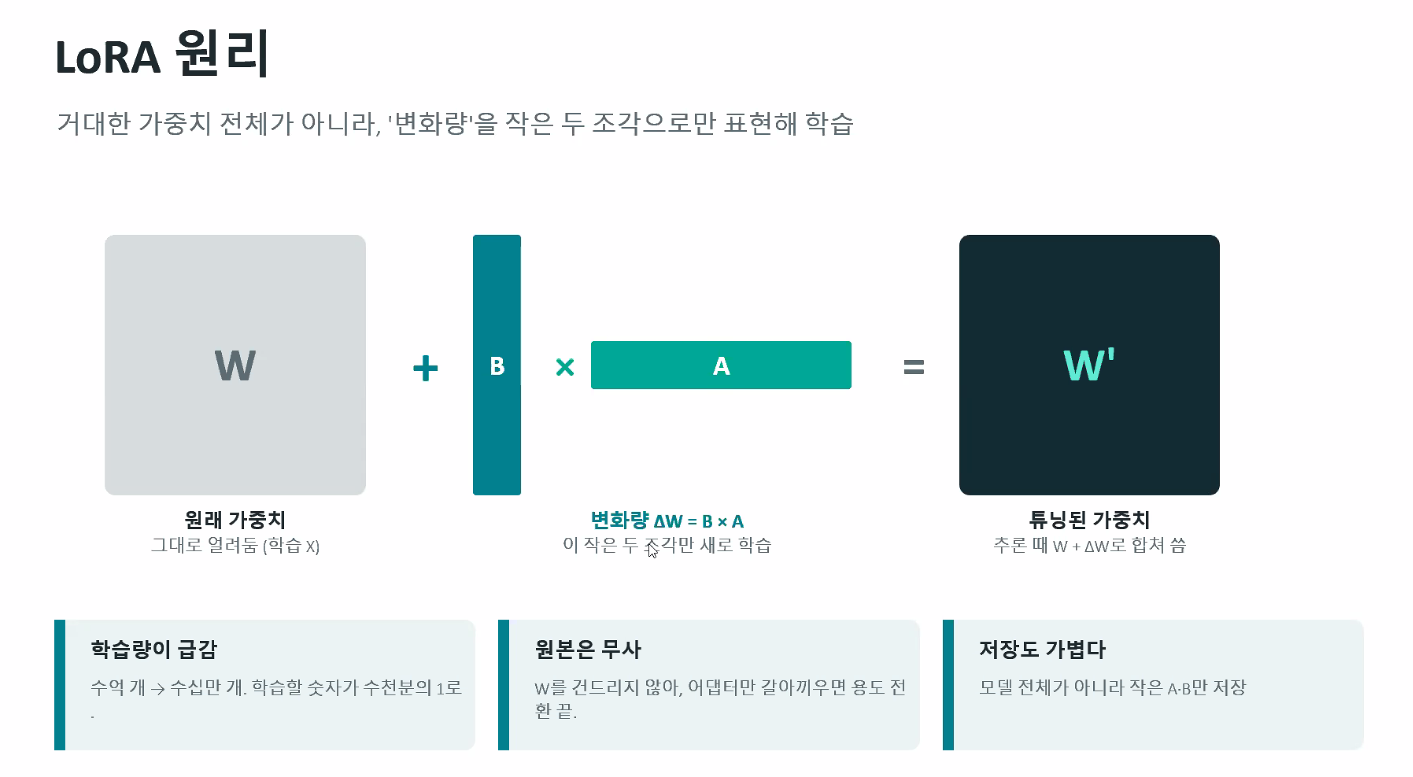

#### 파인튜닝을 위한 두 개의 질문
'얼마나 바꾸나'와 '무엇으로 가르치나'
- Q1. 파라미터를 얼마나 바꾸는지?
  - Full FT: 모든 파라미터를 갱신, 자유도는 최대비만 비용 및 메모리 최대
  - PEFT (LoRA 등): 일부만 갱신. LoRA,Prefix,Adapter.. 사실상 표준

- Q2. 무엇으로 가르치나?
  - SFT 지도학습: input/Target 쌍을 이용하여 따라하게 함.
    - 특정한 경우 이를 해결하는 특정 툴을 검색해오도록 지도하는 등
  - RLHF, DPO(Direct P Optimization) - 선호도 정렬 : 좋은 답/나쁜 답 쌍을 주고, 모델의 '취향'을 맞춤. DPO는 RLHF를 더 간단히 만든 방식.
    - 인간 피드백이 없으면, 평균적인 점수를 잘 맞추는 등으로 수렴할 수 있음.
    - DPO 라벨링 활용, A/B Test ...선호도 학습 및 파인튜닝

- 비지도 학습은, 벡터의 크기, 방향, 위치 등으로 군집화함

#### OpenAI Fine-tuning 4단계
- JSONL(JSON Lines) 형식
- 파일 업로드, job 생성
- 반환된 모델

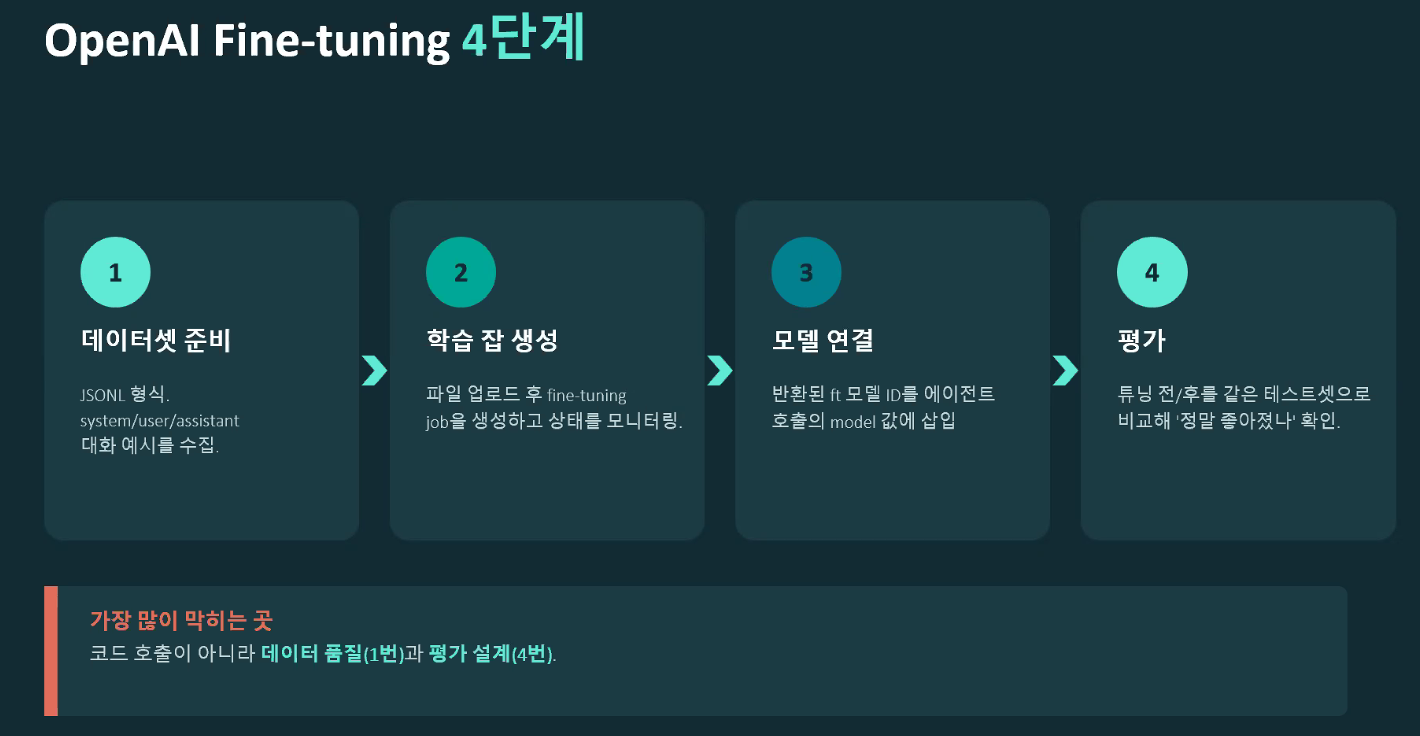

#### 성능 검증
- 지표로 확인(LLM as Judge 또는 로직, TF/IDF 기반 등)
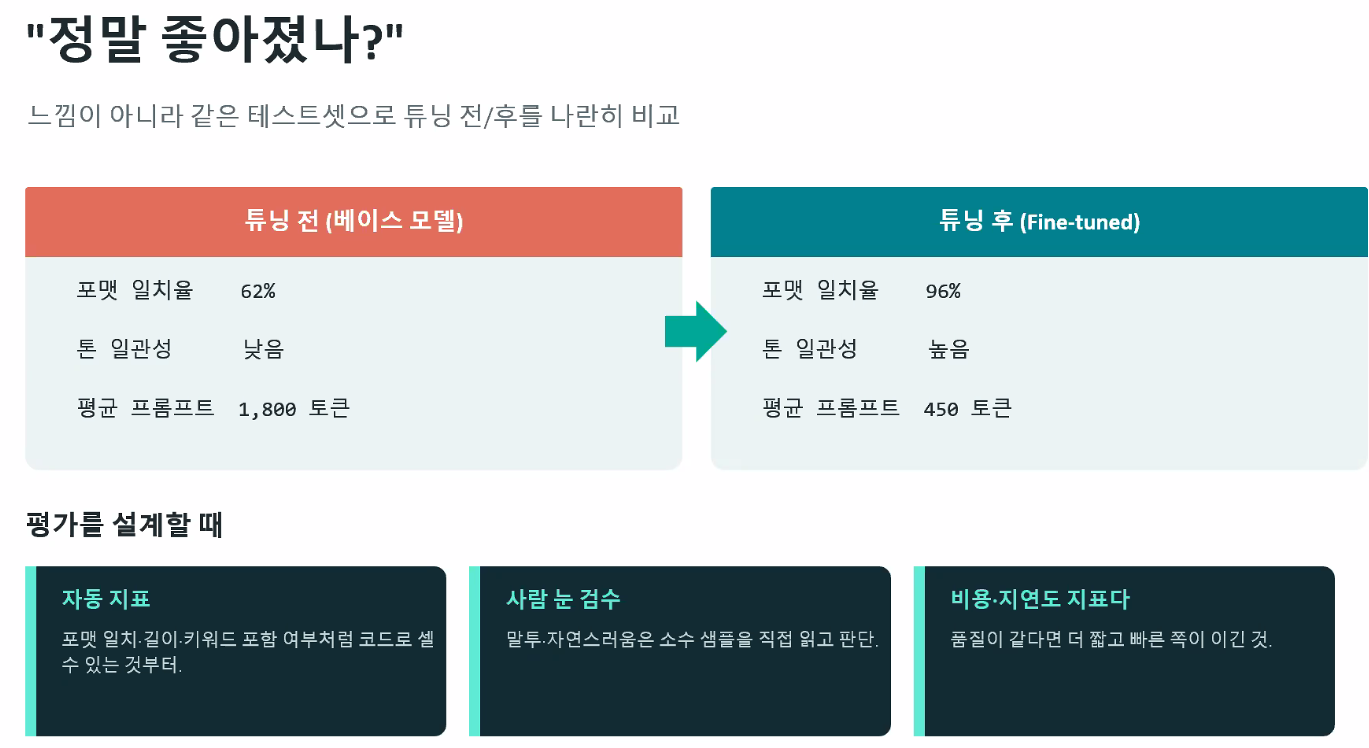

## 코드 실습 — 파인튜닝 파이프라인

In [ ]:
# 환경 설정 및 라이브러리 설치
!pip install -q openai langchain langchain-openai langchain-community faiss-cpu \
    rank_bm25 pandas numpy matplotlib gradio python-dotenv tiktoken

In [ ]:
import os
import json
import time
import random
from pathlib import Path
# from dotenv import load_dotenv
# load_dotenv()
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from openai import OpenAI
oai = OpenAI()
llm = ChatOpenAI(model="gpt-4o-mini")

In [ ]:
WORK_DIR = Path('/content/drive/MyDrive/Colab Notebooks/260509_ft')
WORK_DIR.mkdir(exist_ok = True)

In [ ]:
from dataclasses import dataclass, field

@dataclass
class FTState:
  train_path : Path | None = None
  val_path : Path | None = None
  train_field_id : str | None = None
  val_file_id : str | None = None
  job_id : str | None = None
  ft_model : str | None = None
  notes : list = field(default_factory=list)

In [ ]:
state = FTState()

In [ ]:
for msg in ['start', 'data ready', 'upload done']:
  state.notes.append(msg)

In [ ]:
state

FTState(train_path=None, val_path=None, train_field_id=None, val_file_id=None, job_id=None, ft_model=None, notes=['start', 'data ready', 'upload done'])

In [ ]:
# 파인튜닝 수행할 예시
  # 입력 : 무례하거나 짧은 한국어
  # 출력 : 같은 의미의 정중한 한국어 이메일 문장

In [ ]:
SYSTEM_MSG = "당신은 무례한 문장을 정중한 이메일 문장으로 바꿔주는 어시스턴트입니다."

TASK_SPEC = {
    'name' : 'polite_email_rewriter',
    'input' : '무례하거나 짧은 한국어 한 줄',
    'output' : '정중한 한국어 이메일 문장 1~2 문장',
    'min_examples' : 30,
    'system' : SYSTEM_MSG
}

print(json.dumps(TASK_SPEC, ensure_ascii=False, indent = 2))

{
  "name": "polite_email_rewriter",
  "input": "무례하거나 짧은 한국어 한 줄",
  "output": "정중한 한국어 이메일 문장 1~2 문장",
  "min_examples": 30,
  "system": "당신은 무례한 문장을 정중한 이메일 문장으로 바꿔주는 어시스턴트입니다."
}


In [ ]:
seed_pairs = [
    ("회의 내일로 미뤄.",   "회의를 내일로 변경 가능할지 여쭙고 싶습니다."),
    ("문서 빨리 줘.",       "문서 전달 가능 시점을 알려주실 수 있을까요?"),
    ("이거 다시 해.",       "이 부분은 한 번 더 수정 부탁드려도 될까요?"),
    ("일정 잡아.",          "편하신 일정을 알려주시면 회의를 잡아 두겠습니다."),
    ("왜 답장 안 해.",      "혹시 이전 메일을 확인하셨을지 여쭙고 싶습니다."),
    ("이건 틀렸어.",        "이 부분은 다시 한 번 검토가 필요해 보입니다."),
]

In [ ]:
def to_jsonl_line(system, user, assistant) -> str:
  return json.dumps({'messages' :[
      {'role' : 'system', 'content': system},
      {'role' : 'user', 'content': user}, # 유저가 물어봄
      {'role' : 'assistant', 'content': assistant},
  ]}, ensure_ascii = False)

In [ ]:
seed_path = WORK_DIR / 'seed.jsonl' # Path('/content/drive/MyDrive/Colab Notebooks/260509_ft')
with open(seed_path, 'w', encoding='utf-8') as f:
  for r, p in seed_pairs:
    f.write(to_jsonl_line(SYSTEM_MSG, r, p) + '\n')

In [ ]:
# 새로운 데이터가 입력될 경우
extras = [
    ("자료 빠뜨렸어.",     "자료 한 가지가 누락된 것 같습니다. 확인 부탁드립니다."),
    ("일정 다시 봐.",      "일정을 다시 한 번 확인해 주실 수 있을까요?"),
    ("이름 잘못 적었어.",  "이름 표기를 한 번 더 확인해 주시면 감사하겠습니다."),
    ("결재 빨리 해.",      "결재 처리 가능 시점을 알려주실 수 있을까요?"),
]

# 'a' 모드로 열기
seed_path = WORK_DIR / 'seed.jsonl' # Path('/content/drive/MyDrive/Colab Notebooks/260509_ft')
with open(seed_path, 'a', encoding='utf-8') as f:
  for r, p in extras:
    f.write(to_jsonl_line(SYSTEM_MSG, r, p) + '\n')

In [ ]:
import re
AUG_SYS = '당신은 학습용 데이터 페어를 생성하는 전문가입니다. 출력은 반드시 JSON 배열로'

def make_augment_prompt(pairs, n=8):
    sample = '\n'.join(f'- "{r}" -> "{p}"' for r, p in pairs[:4])
    return (f"다음은 무례한 문장 -> 정중한 이메일 문장 페어입니다.\n"
            f"같은 스타일,길이 분포로 새 페어 {n} 쌍을 한국어로 만드세요.\n"
            f"출력 형식: [{{\"rude\":\"...\",\"polite\":\"...\"}}, ...]\n\n예시:\n{sample}")


resp = llm.invoke([SystemMessage(content = AUG_SYS),
                   HumanMessage(content = make_augment_prompt(seed_pairs, n = 10))
                   ]).content
print(resp[:100])

[
    {"rude":"내일 회의 안 나와도 돼.","polite":"내일 회의에 참석하지 않으셔도 괜찮으시겠습니까?"},
    {"rude":"보고서 오늘 안에 제출해.",


In [ ]:
print(resp[:300])

[
    {"rude":"내일 회의 안 나와도 돼.","polite":"내일 회의에 참석하지 않으셔도 괜찮으시겠습니까?"},
    {"rude":"보고서 오늘 안에 제출해.","polite":"보고서를 오늘 중에 제출해 주실 수 있을까요?"},
    {"rude":"시간 없어.","polite":"지금 시간이 조금 여유가 없는데, 나중에 이야기해도 괜찮을까요?"},
    {"rude":"그거 그만해.","polite":"그 부분은 한 번 중단해 주실 수 있을까요?"}, 
    {"rude":"메일 빨리 답해.","polit


In [ ]:
# 기존 gpt-4o-mini -> gpt-4o-mini-finetune260519 -> gpt-4o-mini-finetune260519_2...
# 계속 파인튜닝

In [ ]:
def parse_pairs(text):
  m = re.search(r"\[.*\]", text, re.DOTALL)
  if not m:
    return []
  try:
    return [(it['rude'], it['polite'] ) for it in json.loads(m.group(0))]
  except Exception:
    return []

augmented = parse_pairs(resp)

In [ ]:
augmented

[('내일 회의 안 나와도 돼.', '내일 회의에 참석하지 않으셔도 괜찮으시겠습니까?'),
 ('보고서 오늘 안에 제출해.', '보고서를 오늘 중에 제출해 주실 수 있을까요?'),
 ('시간 없어.', '지금 시간이 조금 여유가 없는데, 나중에 이야기해도 괜찮을까요?'),
 ('그거 그만해.', '그 부분은 한 번 중단해 주실 수 있을까요?'),
 ('메일 빨리 답해.', '메일에 대한 회신을 빠른 시일 내에 주실 수 있나요?'),
 ('나 대신 해줘.', '이 일을 대신 처리해 주실 수 있으신가요?'),
 ('이거 언제 끝내.', '이 일을 언제 완료하실 수 있는지 여쭤봐도 될까요?'),
 ('다시 설명해.', '이 부분에 대해 다시 한 번 설명해 주실 수 있으신가요?'),
 ('그것 하지 마.', '해당 사항은 진행하지 말아 주시겠어요?'),
 ('내일까지 결과 내.', '내일까지 결과를 알려주실 수 있을까요?')]

In [ ]:
# 검증
# llm -> evaluate -> 좋은애들만 남겨라..
  # llm만 이용하여 검증하는 것 보다는 다른 기법도 사용
# 구조, 길이(및 빈 응답), 중복된 응답 등

import tiktoken

enc = tiktoken.get_encoding('cl100k_base') # gpt-4o-mini에서 사용하는 인코더와 동일

In [ ]:
MAX_TOKENS_PER_SAMPLE = 4096

def check_sample(row) -> list[str]:
  errs = []
  msgs = row.get('messages', [])
  roles = {m.get('role') for m in msgs}
  if not {'system', 'user', 'assistant'} <= roles: # roles에 없으면 에러에 추가
    errs.append('필수 role 누락됨')
  # 예외를 계속 추가
  if not any(m.get('role') == 'assistant' and m.get('content') for m in msgs):
    errs.append('assistant 응답 누락')
  total = sum(len(enc.encode(m.get('content', ''))) for m in msgs)
  if total > MAX_TOKENS_PER_SAMPLE:
    errs.append('토큰 개수 초과')
  return errs

In [ ]:
def validate(path):
  seen, bad, rows = set(), [], []
  # path에 있는 파일을 열어서 한줄씩 볼 예정
  for i, line in enumerate(open(path, encoding='utf-8')):
    try:
      row = json.loads(line)
    except:
      bad.append((i, "json 파싱 실패"))
      continue
    errs = check_sample(row)
    user_msg = next((m['content'] for m in row.get('messages', []) if m['role'] == 'user'), '')
    if user_msg in seen:
      errs.append('user 중복')
    seen.add(user_msg)
    (bad if errs else rows).append((i, ", ".join(errs)) if errs else row)
  return rows, bad

In [ ]:
# 페어 리스트를 받아서 -> jsonl 빌드를 하는 함수

def pairs_to_jsonl(pairs :list[tuple[str,str]], system: str, out_path : Path):
  # to_jsonl_line() -> out_path에 한줄씩 write 하는 함수

    n = 0

    with open(out_path, "w", encoding="utf-8") as f:
      for r, p in pairs:
        f.write(to_jsonl_line(system, r, p) + "\n")
        n += 1

    return n

In [ ]:
aug_path = WORK_DIR / 'aug.jsonl'
n = pairs_to_jsonl(augmented, SYSTEM_MSG, aug_path)
n

10

In [ ]:
combined = WORK_DIR / 'combined.jsonl'
with open(combined, 'w', encoding='utf-8') as f:
  for src in [seed_path, aug_path]:
    if src.exists():
      f.write(open(src).read())

ok, bad = validate(combined)


In [ ]:
ok, bad

([{'messages': [{'role': 'system',
     'content': '당신은 무례한 문장을 정중한 이메일 문장으로 바꿔주는 어시스턴트입니다.'},
    {'role': 'user', 'content': '회의 내일로 미뤄.'},
    {'role': 'assistant', 'content': '회의를 내일로 변경 가능할지 여쭙고 싶습니다.'}]},
  {'messages': [{'role': 'system',
     'content': '당신은 무례한 문장을 정중한 이메일 문장으로 바꿔주는 어시스턴트입니다.'},
    {'role': 'user', 'content': '문서 빨리 줘.'},
    {'role': 'assistant', 'content': '문서 전달 가능 시점을 알려주실 수 있을까요?'}]},
  {'messages': [{'role': 'system',
     'content': '당신은 무례한 문장을 정중한 이메일 문장으로 바꿔주는 어시스턴트입니다.'},
    {'role': 'user', 'content': '이거 다시 해.'},
    {'role': 'assistant', 'content': '이 부분은 한 번 더 수정 부탁드려도 될까요?'}]},
  {'messages': [{'role': 'system',
     'content': '당신은 무례한 문장을 정중한 이메일 문장으로 바꿔주는 어시스턴트입니다.'},
    {'role': 'user', 'content': '일정 잡아.'},
    {'role': 'assistant', 'content': '편하신 일정을 알려주시면 회의를 잡아 두겠습니다.'}]},
  {'messages': [{'role': 'system',
     'content': '당신은 무례한 문장을 정중한 이메일 문장으로 바꿔주는 어시스턴트입니다.'},
    {'role': 'user', 'content': '왜 답장 안 해.'},
    {'role': 'assista

In [ ]:
def filter_clean(in_path:Path, out_path:Path) -> dict:  # jsonl 파일을 받아서 -> validate Ok, Bad -> ok만 out_path에 저장
    ok_rows, bad_rows = validate(in_path)
    with open(out_path, 'w', encoding='utf-8') as f:
        for row in ok_rows:
            f.write(json.dumps(row, ensure_ascii=False) + '\n')
    total = len(ok_rows) + len(bad_rows)
    pct = (len(ok_rows) / total * 100) if total else 0.0
    return {'ok' : len(ok_rows), 'bad' : len(bad_rows), 'pass_rate' : pct}

In [ ]:
clean_path = WORK_DIR / "clean.jsonl"
filter_clean(aug_path, clean_path)

{'ok': 10, 'bad': 0, 'pass_rate': 100.0}

In [ ]:
# train val test

In [ ]:
def split_jsonl(in_path, train_path, val_path, val_ratio = 0.2, seed = 42):
  rows = [json.loads(l) for l in open(in_path, encoding='utf-8')]
  random.Random(seed).shuffle(rows)
  n_val = max(1, int(len(rows) * val_ratio))
  val, train = rows[:n_val], rows[n_val:]
  for path, data in [(train_path, train), (val_path, val)]:
    with open(path, 'w', encoding='utf-8') as f:
        for row in data:
            f.write(json.dumps(row, ensure_ascii=False) + '\n')
  return len(train), len(val)



In [ ]:
state.train_path = WORK_DIR / 'train.jsonl'
state.val_path = WORK_DIR / 'val.jsonl'

n_tr, n_vl = split_jsonl(clean_path, state.train_path, state.val_path)

In [ ]:
n_tr, n_vl

(8, 2)

In [ ]:
# 100%
# 80% 한국어, 10% 영어, 10% 스페인어 -> 모델 성능에 영향을 미침

In [ ]:
# k-fold validation
# 80% train, 20% validation
# 100만개, 5세트로 나눔

# 1: 20만 /2: 20만 /3: 20만 /4: 20만/5: 20만

# 1 2 3 4 -> 5 val
# 1 2 3   5  -> 4 val
# 1 2   4 5    -> 3 val
# ...

# k개 셋트로 분할 후 각각의 그룹

In [ ]:
# 신용카드 fraud detect (사기건수) -> 사기 건수 자체가 부족..

In [ ]:
def kfold_indices(n, k, seed=42) -> list[tuple[list[int], list[int]]]:
  if k> n:
    raise ValueError(f"k{k} > n{n}")
  idx = list(range(n))
  random.Random(seed).shuffle(idx)
  folds = []
  for i in range(k):
    val = idx[i::k]
    train = [x for x in idx if x not in set(val)]
    folds.append((train,val))
  return folds


In [ ]:
folds = kfold_indices(10,5)

In [ ]:
folds

[([3, 2, 8, 5, 9, 4, 0, 1], [7, 6]),
 ([7, 2, 8, 5, 6, 4, 0, 1], [3, 9]),
 ([7, 3, 8, 5, 6, 9, 0, 1], [2, 4]),
 ([7, 3, 2, 5, 6, 9, 4, 1], [8, 0]),
 ([7, 3, 2, 8, 6, 9, 4, 0], [5, 1])]

In [ ]:
# 업로드
# oai.files.create(file=파일경로, purpose='fine-tune')

def upload_jsonl(path):
  with open(path, 'rb') as f:
    result = oai.files.create(file=f, purpose='fine-tune')
  return result.id

In [ ]:
state

FTState(train_path=PosixPath('/content/drive/MyDrive/Colab Notebooks/260509_ft/train.jsonl'), val_path=PosixPath('/content/drive/MyDrive/Colab Notebooks/260509_ft/val.jsonl'), train_field_id=None, val_file_id=None, job_id=None, ft_model=None, notes=['start', 'data ready', 'upload done'])

In [ ]:
state.train_file_id = upload_jsonl(state.train_path)

In [ ]:
state.val_file_id = upload_jsonl(state.val_path)

In [ ]:
state.train_file_id, state.val_file_id

('file-RQbTmeGwBqQjKE2aLUcW5u', 'file-51nV6SakzP3rxJobE3mDbJ')

In [ ]:
oai.files.list().data

[FileObject(id='file-51nV6SakzP3rxJobE3mDbJ', bytes=607, created_at=1779280973, filename='val.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None),
 FileObject(id='file-RQbTmeGwBqQjKE2aLUcW5u', bytes=2472, created_at=1779280972, filename='train.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None),
 FileObject(id='file-Qqc3GfQibb8GZqgH4wx8eC', bytes=588, created_at=1779276264, filename='val.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None),
 FileObject(id='file-D3VmMbjMNAQYR9d1kenCJC', bytes=2359, created_at=1779276247, filename='train.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)]

In [ ]:
def list_ft_files(client, purpose = 'fine-tune', limit=5):
  items = client.files.list().data
  matched = [f for f in items if getattr(f, 'purpose', '') == purpose]
  matched.sort(key = lambda f: getattr(f, 'created_at', 0), reverse = True)
  return [{'id': f.id, "filename":f.filename, 'bytes': getattr(f, 'bytes',0)} for f in matched[:limit]]

In [ ]:
  BASE_MODEL = 'gpt-4o-mini-2024-07-18'

In [ ]:
oai.fine_tuning.jobs.create(
    training_file = state.train_file_id ,Q
    validation_file = state.val_file_id,
    model = BASE_MODEL,
    suffix = "modu-polite-email",
    hyperparameters = {'n_epochs' : 'auto'}
)

# OpenAI 공식 문서 기준으로, 2026년 5월 7일부터 이전에 fine-tuning을 실행한 적 없는 조직은
# 새 fine-tuning training job을 만들 수 없도록 제한되었습니다.
# 또한 fine-tuned model의 inference는 base model이 deprecated될 때까지 유지되지만,
# 새 학습 job 생성은 단계적으로 중단됩니다

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3817406779.py, line 2)

In [ ]:
def build_job_payload(state, base_model, suffix, n_epochs = 'auto') -> dict:

In [ ]:
class PoliteRewriter:
    def __init__(self, model_name):
        self.model_name = model_name
        self._cache: dict[str, str] = {}
        self.hits = 0
        self.misses = 0

    def rewrite(self, text: str) -> str:
        if text in self._cache:
            self.hits += 1
            return self._cache[text]

        self.misses += 1
        llm = ChatOpenAI(model=self.model_name)
        out = llm.invoke([SystemMessage, HumanMessage])
        return out.content

    def batch(self, texts: list[str]) -> list[str]:
        pass

### 허깅페이스

In [ ]:
!pip install -q -U "transformers>=4.45" "trl>=0.11" "peft>=0.13" \
    "datasets>=2.20" "accelerate>=0.34" "tokenizers>=0.20"

In [2]:
import torch, transformers, trl, peft, datasets

ModuleNotFoundError: No module named 'trl'

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
MODEL_ID = 'Qwen/Qwen2.5-1.5B-Instruct'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
tokenizer.pad_token # 문장과 문장 사이의 패딩, 문장이 끝났다는 것을 알려줌(eos와 비슷하긴함)

'<|endoftext|>'

In [ ]:
tokenizer.eos_token # end of sentence

'<|im_end|>'

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype = torch.bfloat16,
    device_map = 'auto'
)

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
sum(p.numel() for p in model.parameters())

1543714304

In [ ]:
WORK_DIR

PosixPath('/content/drive/MyDrive/Colab Notebooks/260509_ft')

In [ ]:
from pathlib import Path
from datasets import load_dataset
# WORK_DIR

TRAIN_PATH = WORK_DIR / 'train.jsonl'
VAL_PATH = WORK_DIR /  'val.jsonl'

In [ ]:
ds = load_dataset('json', data_files = {'train': str(TRAIN_PATH), 'validation': str(VAL_PATH)})

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

In [ ]:
ds['train'][0]['messages']

[{'role': 'system', 'content': '당신은 무례한 문장을 정중한 이메일 문장으로 바꿔주는 어시스턴트입니다.'},
 {'role': 'user', 'content': '시간 없어.'},
 {'role': 'assistant', 'content': '지금 시간이 조금 여유가 없는데, 나중에 이야기해도 괜찮을까요?'}]

In [ ]:
print(tokenizer.apply_chat_template(ds['train'][0]['messages'], tokenize = False, add_generation_prompt=False))

<|im_start|>system
당신은 무례한 문장을 정중한 이메일 문장으로 바꿔주는 어시스턴트입니다.<|im_end|>
<|im_start|>user
시간 없어.<|im_end|>
<|im_start|>assistant
지금 시간이 조금 여유가 없는데, 나중에 이야기해도 괜찮을까요?<|im_end|>



In [ ]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

In [ ]:
lora_cfg = LoraConfig(
    r = 16,
    lora_alpha = 32,
    lora_dropout = 0.05,
    bias = 'none',
    task_type = 'CAUSAL_LM',
    target_modules = [
        'q_proj', 'k_proj', 'v_proj', 'o_proj'
    ]
 )

In [1]:
MODEL_ID

NameError: name 'MODEL_ID' is not defined

In [ ]:
model

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps=1e-06)
    (rotar

In [ ]:
from trl import SFTTrainer, SFTConfig

OUTPUT_DIR = 'qwen25-1.5b_polite_email_lora'

sft_cfg = SFTConfig(
    output_dir = OUTPUT_DIR,
    num_train_epochs = 8,
    per_device_train_batch_size = 2,
    per_device_eval_batch_size = 2,
    bf16=True,

    # gradient_accumulation_steps = 4, batch_size가 너무 작은 경우, "4개 step의 평균값을 이용하여 gradient를 업데이트 해라" 라는 뜻
    # learning_rate,
    # warmup_ratio,
    # lr_scheduler_type,
)

In [ ]:
trainer = SFTTrainer(
    model = model,
    args = sft_cfg,
    train_dataset = ds['train'],
    eval_dataset = ds['validation'],
    processing_class = tokenizer
)

In [ ]:
def generate(user_msg, max_new_tokens):
  msgs = [
      {'role': 'system', 'content' : SYSTEM_MSG},
      {'role': 'user', 'content' : user_msg}
  ]

  inputs = tokenizer.apply_chat_template(
      msgs,
      tokenize = True,
      add_generation_prompt = True,
      return_tensors = 'pt'
      return_dict = True
  ).to(device)

  with torch.no_grad():
    out = model.generate(
        **inputs,
        max_new_tokens = max_new_tokens,
        do_sample = False,
        pad_token_id = tokenizer.eos_token_id,
    )

  prompt_len = inputs['input_ids'].shape[1]
  return tokenizer.decode(out[0,prompt_len:], skip_special_tokens=True).strip()
